In [ ]:
%pip install matplotlib plotly

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------------- ---------------------- 3.7/8.3 MB 19.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 23.6 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 79.2 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 93.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 103.6 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillo

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [11]:
df = pd.read_excel(r'C:\Users\camil\OneDrive\Escritorio\ETL_python\Data\DTM_Mixed Migration Flows to Europe_Yearly_2024_1.xlsx', sheet_name= 'First_Arrival_Countries_CoO')
df.head()

,Date,Year,Month,ISO3 - Country of origin,ISO3 - Country of arrival,Route,Arrivals,Source
0,2024-01-31,2024,1,BGD,MLT,CMR,7,"Maltese Minitry of Home Affairs, Security and ..."
1,2024-01-31,2024,1,EGY,MLT,CMR,1,"Maltese Minitry of Home Affairs, Security and ..."
2,2024-01-31,2024,1,PAK,MLT,CMR,22,"Maltese Minitry of Home Affairs, Security and ..."
3,2024-01-31,2024,1,SDN,MLT,CMR,1,"Maltese Minitry of Home Affairs, Security and ..."
4,2024-01-31,2024,1,SYR,MLT,CMR,4,"Maltese Minitry of Home Affairs, Security and ..."


In [14]:
df.rename(columns={'ISO3 - Country of origin':'Origin','ISO3 - Country of arrival':'Destination'}, inplace=True)
df.head()

,Date,Year,Month,Origin,Destination,Route,Arrivals,Source
0,2024-01-31,2024,1,BGD,MLT,CMR,7,"Maltese Minitry of Home Affairs, Security and ..."
1,2024-01-31,2024,1,EGY,MLT,CMR,1,"Maltese Minitry of Home Affairs, Security and ..."
2,2024-01-31,2024,1,PAK,MLT,CMR,22,"Maltese Minitry of Home Affairs, Security and ..."
3,2024-01-31,2024,1,SDN,MLT,CMR,1,"Maltese Minitry of Home Affairs, Security and ..."
4,2024-01-31,2024,1,SYR,MLT,CMR,4,"Maltese Minitry of Home Affairs, Security and ..."


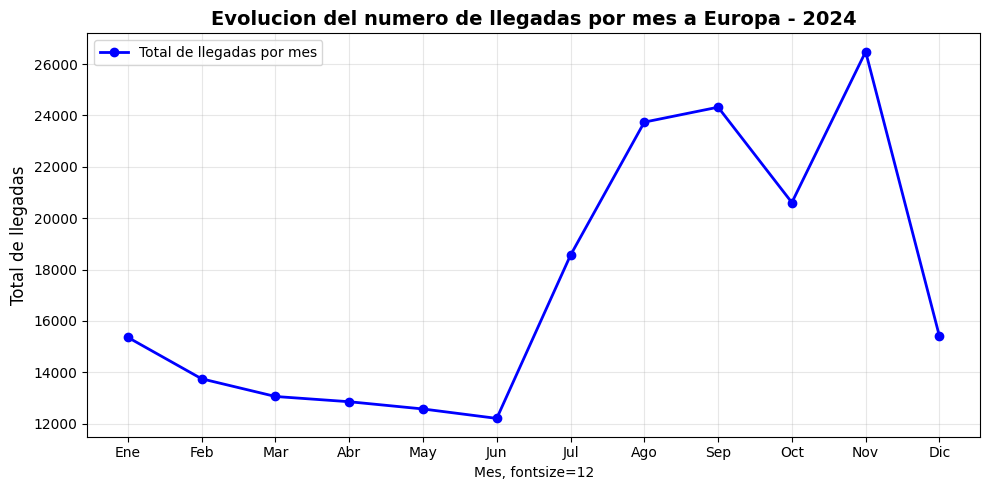

In [15]:
llegadas_por_mes = df.groupby('Month')['Arrivals'].sum()

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    llegadas_por_mes.index,
    llegadas_por_mes.values,
    marker='o',
    color='blue',
    linewidth=2,
    label='Total de llegadas por mes'
)

ax.set_title('Evolucion del numero de llegadas por mes a Europa - 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes, fontsize=12')
ax.set_ylabel('Total de llegadas', fontsize=12)

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

ax.set_xticks(range(1,13))
ax.set_xticklabels(meses)

ax.legend()

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
df_llegadas_por_mes_ESP = df[df['Destination']== 'ESP']
df_llegadas_por_mes_ESP.head


<bound method NDFrame.head of            Date  Year  Month Origin Destination Route  Arrivals  \
882  2024-01-31  2024      1    BEN         ESP   WMR         1   
883  2024-01-31  2024      1    BFA         ESP  WAAR        12   
884  2024-01-31  2024      1    BGD         ESP  WAAR         1   
885  2024-01-31  2024      1    BGD         ESP   WMR        11   
886  2024-01-31  2024      1    CAF         ESP  WAAR         3   
...         ...   ...    ...    ...         ...   ...       ...   
1400 2024-12-31  2024     12    SYR         ESP   WMR        39   
1401 2024-12-31  2024     12    TCD         ESP  WAAR         4   
1402 2024-12-31  2024     12    TCD         ESP   WMR         2   
1403 2024-12-31  2024     12    TGO         ESP  WAAR         6   
1404 2024-12-31  2024     12    YEM         ESP  WAAR        16   

                                      Source  
882   European Border and Coast Guard Agency  
883   European Border and Coast Guard Agency  
884   European Border an

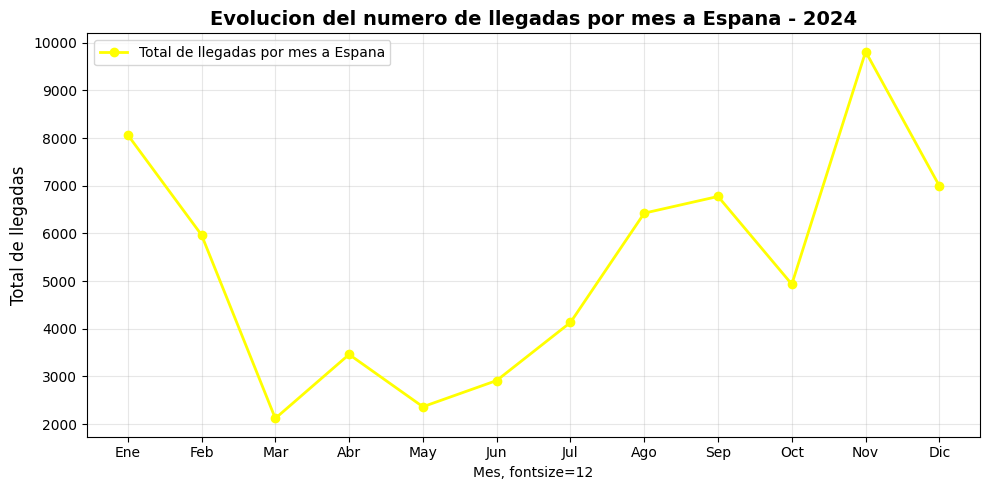

In [32]:
llegadas_esp = df_llegadas_por_mes_ESP.groupby('Month')['Arrivals'].sum()

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    llegadas_esp.index,
    llegadas_esp.values,
    marker='o',
    color='yellow',
    linewidth=2,
    label='Total de llegadas por mes a Espana'
)

ax.set_title('Evolucion del numero de llegadas por mes a Espana - 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes, fontsize=12')
ax.set_ylabel('Total de llegadas', fontsize=12)

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

ax.set_xticks(range(1,13))
ax.set_xticklabels(meses)

ax.legend()

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

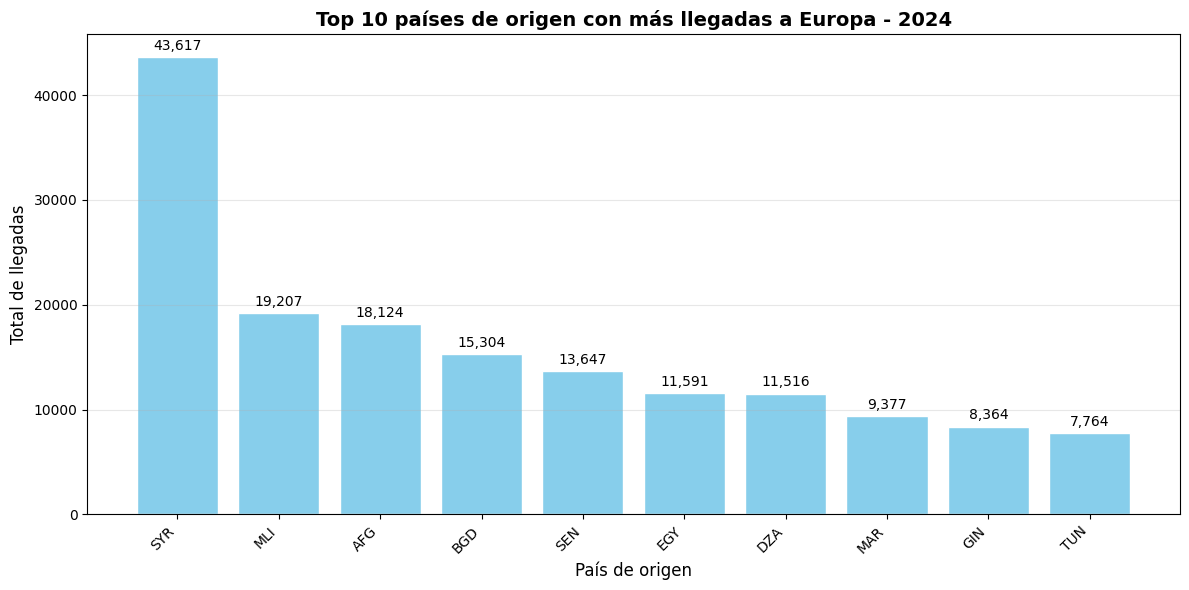

In [41]:
top10_origenes = df.groupby('Origin')['Arrivals'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))

barras = ax.bar(
    top10_origenes.index,
    top10_origenes.values,
    color='skyblue',
    edgecolor='white')

ax.bar_label(barras, labels=[f'{x:,}' for x in top10_origenes.values], padding=3, fontsize=10)
ax.set_title('Top 10 países de origen con más llegadas a Europa - 2024', fontsize=14, fontweight='bold')

ax.set_xlabel('País de origen', fontsize=12)
ax.set_ylabel('Total de llegadas', fontsize=12) 

plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Tabla cruzada (Trimestre vs Destino):


Destination,ESP,GRC,ITA
Trimestre,,,
Q1,16156,10565,11416
Q2,8742,10154,14599
Q3,17333,20235,23676
Q4,21739,21089,16926


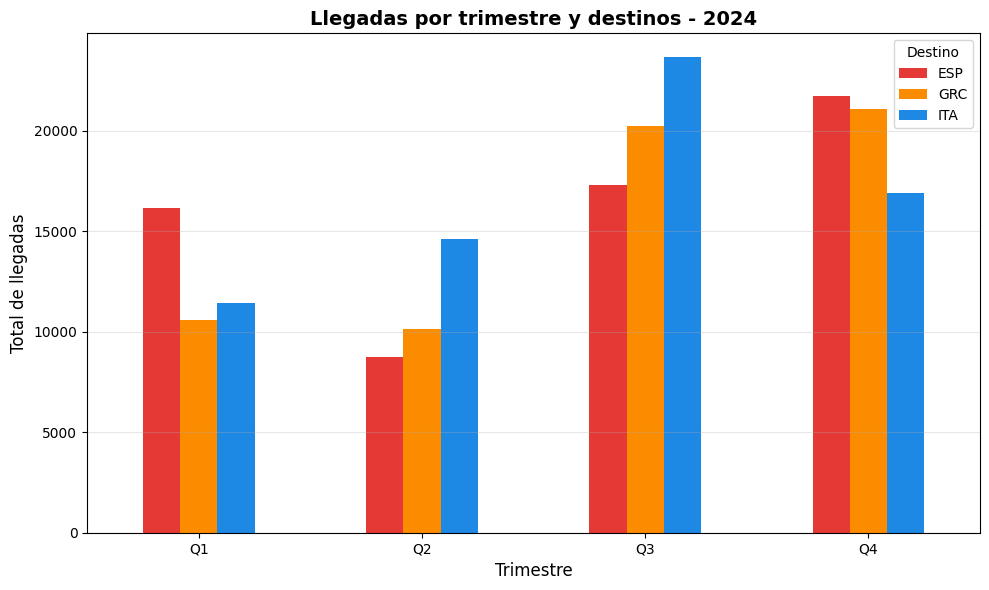

In [39]:
#creamos la columna de trimestre
df['Trimestre'] = pd.cut(df['Month'], bins=[0, 3, 6, 9, 12], labels=['Q1', 'Q2', 'Q3', 'Q4'])

top3_destinos = ['ITA', 'ESP', 'GRC']
df_top3 = df[df['Destination'].isin(top3_destinos)]

tabla_trimestre = df_top3.pivot_table(
    index='Trimestre', 
    columns='Destination', 
    values='Arrivals', 
    aggfunc='sum')

print("Tabla cruzada (Trimestre vs Destino):")
display(tabla_trimestre)

fig, ax = plt.subplots(figsize=(10, 6))
tabla_trimestre.plot(kind='bar', ax=ax, color=['#E53935', '#FB8C00', '#1E88E5'])

ax.set_title('Llegadas por trimestre y destinos - 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Trimestre', fontsize=12)
ax.set_ylabel('Total de llegadas', fontsize=12)
ax.legend(title='Destino')

plt.xticks(rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()